# 05 — Scoring en Vivo

Aplica el modelo entrenado sobre mercados **activos** para generar señales de compra.

**Prerequisitos:**
```bash
# Modelo entrenado
python -m src.model.train --data-dir data/processed --epochs 50

# O desde el notebook 04_model_training.ipynb
```

**Secciones:**
1. Cargar modelo y pipeline
2. Puntuar mercados activos usando `price_histories` + `order_books` cacheados
3. Top-K señales con clasificación STRONG BUY / BUY / HOLD
4. Filtros de calidad (liquidez, spread, volumen)
5. Backtesting sobre resueltos con snapshot anti-leakage
6. Simulación de P&L


In [1]:
import sys
import json
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.data.preprocessing import build_snapshot_market, infer_resolution_from_market
from src.scoring.signals import generate_signals

logging.getLogger('src.data.preprocessing').setLevel(logging.ERROR)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
MODEL_DIR = ROOT / cfg['training']['save_dir']
PROCESSED = ROOT / cfg['data']['processed_dir']
RAW = ROOT / cfg['data']['raw_dir']
SCORING_CFG = cfg['scoring']
FEATURE_CFG = cfg['features']

BUY_THRESHOLD = SCORING_CFG['buy_threshold']
STRONG_BUY_THRESHOLD = SCORING_CFG['strong_buy_threshold']
MIN_LIQUIDITY = SCORING_CFG['min_liquidity']
MIN_VOLUME_24H = SCORING_CFG['min_volume_24h']
MAX_SPREAD = SCORING_CFG['max_spread']

model_path = MODEL_DIR / 'best_market_model.pt'
metrics_path = MODEL_DIR / 'test_metrics.json'
pipeline_dir = PROCESSED / 'pipeline'

assert model_path.exists(), f'Modelo no encontrado: {model_path}. Entrenar primero con src.model.train o notebook 04.'
assert pipeline_dir.exists(), f'Pipeline no encontrado: {pipeline_dir}. Correr primero src.features.pipeline.'
print('Modelo y pipeline disponibles.')
if metrics_path.exists():
    test_metrics = json.loads(metrics_path.read_text())
    print('Resumen held-out del modelo baseline:')
    print(json.dumps(test_metrics['default_threshold'], indent=2))


Modelo y pipeline disponibles.
Resumen held-out del modelo baseline:
{
  "threshold": 0.5,
  "accuracy": 0.9127855235835064,
  "precision": 0.7780082987551867,
  "recall": 0.9036144578313253,
  "f1": 0.8361204013377926,
  "pr_auc": 0.942834468850521,
  "roc_auc": 0.9784858442032592,
  "classification_report": "              precision    recall  f1-score   support\n\n      No Buy     0.9668    0.9158    0.9406      2541\n         Buy     0.7780    0.9036    0.8361       830\n\n    accuracy                         0.9128      3371\n   macro avg     0.8724    0.9097    0.8884      3371\nweighted avg     0.9203    0.9128    0.9149      3371\n",
  "confusion_matrix": [
    [
      2327,
      214
    ],
    [
      80,
      750
    ]
  ]
}


## 1. Cargar modelo y pipeline

In [2]:
from src.features.pipeline import FeaturePipeline
from src.model.architecture import MarketValueNet

pipeline = FeaturePipeline.load(str(pipeline_dir), use_dummy_text=False)
model = MarketValueNet(
    num_numerical_features=pipeline.num_numerical_features,
    num_categories=pipeline.num_categories,
    text_embed_dim=pipeline.text_embed_dim,
    hidden_dims=cfg['model']['hidden_dims'],
    dropout=cfg['model']['dropout'],
    task='classification',
)
model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

print(f"Modelo cargado desde {model_path}")
print(f"  num_numerical_features: {pipeline.num_numerical_features}")
print(f"  num_categories:         {pipeline.num_categories}")
print(f"  text_embed_dim:         {pipeline.text_embed_dim}")
print(f"  Dispositivo:            {device}")


Modelo cargado desde /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/models/market_value_baseline/best_market_model.pt
  num_numerical_features: 23
  num_categories:         10
  text_embed_dim:         384
  Dispositivo:            cpu


## 2. Puntuar mercados activos

Usamos los mercados activos descargados en `data/raw/active_markets.json`.
Para alinear el notebook con `src.scoring.scorer`, pasamos también
`price_histories.json` y `order_books.json` cacheados al pipeline.


In [3]:
with open(RAW / 'active_markets.json') as f:
    active_markets = json.load(f)
with open(RAW / 'price_histories.json') as f:
    price_histories = json.load(f)
with open(RAW / 'order_books.json') as f:
    order_books = json.load(f)

print(f'Mercados activos cargados: {len(active_markets):,}')

results = []
skipped = 0
missing_context = {'history': 0, 'order_book': 0}

for market in active_markets:
    market_id = str(market.get('id', ''))
    history = price_histories.get(market_id)
    order_book = order_books.get(market_id)
    if not history:
        missing_context['history'] += 1
    if not order_book:
        missing_context['order_book'] += 1

    try:
        features = pipeline.transform_single(market, price_history=history, order_book=order_book)

        num_t = torch.FloatTensor(features['numerical']).unsqueeze(0).to(device)
        cat_t = torch.LongTensor([features['category_id']]).to(device)
        txt_t = torch.FloatTensor(features['text_embedding']).unsqueeze(0).to(device)

        with torch.no_grad():
            score = model(num_t, cat_t, txt_t).item()

        outcome_prices = market.get('outcomePrices', [0.5])
        if isinstance(outcome_prices, str):
            try:
                outcome_prices = json.loads(outcome_prices)
            except Exception:
                outcome_prices = []
        price_yes = float(outcome_prices[0]) if outcome_prices else float(market.get('lastTradePrice') or 0.5)

        results.append({
            'id': market_id,
            'question': market.get('question', ''),
            'price_yes': price_yes,
            'volume_24h': float(market.get('volume24hr') or 0),
            'liquidity': float(market.get('liquidity') or 0),
            'spread': float(market.get('spread') or 0),
            'model_score': score,
            'end_date': market.get('endDate', ''),
            'slug': market.get('slug', ''),
        })
    except Exception:
        skipped += 1

df_scores = pd.DataFrame(results).sort_values('model_score', ascending=False).reset_index(drop=True)
print(f'Puntuados: {len(df_scores):,} | Omitidos: {skipped}')
print('Contexto faltante en cache local:')
for key, value in missing_context.items():
    print(f'  {key}: {value:,}')
print()
print('Distribución de scores:')
print(df_scores['model_score'].describe().round(4))


Mercados activos cargados: 900


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Puntuados: 900 | Omitidos: 0
Contexto faltante en cache local:
  history: 0
  order_book: 0

Distribución de scores:
count    900.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: model_score, dtype: float64


## 3. Top-K señales con clasificación

El `model_score` es un score de clasificación, **no una probabilidad calibrada**.
Usarlo como **ranking relativo** entre mercados, no como retorno esperado.
La señal final se construye con `generate_signals(...)`, que además aplica
filtros de calidad por liquidez, volumen y spread.

| Score | Señal |
|---|---|
| ≥ 0.75 | STRONG BUY |
| ≥ 0.60 | BUY |
| < 0.60 | HOLD |


In [4]:
df_scores = generate_signals(
    df_scores,
    buy_threshold=BUY_THRESHOLD,
    strong_buy_threshold=STRONG_BUY_THRESHOLD,
    min_liquidity=MIN_LIQUIDITY,
    min_volume_24h=MIN_VOLUME_24H,
    max_spread=MAX_SPREAD,
)

signal_counts = df_scores['signal'].value_counts()
print('Distribución de señales:')
for signal, count in signal_counts.items():
    print(f'  {signal:12s}: {count:,} ({100 * count / len(df_scores):.1f}%)')

print()
print('-' * 120)
print(f"{'#':>3} {'SEÑAL':12} {'SCORE':6} {'PRECIO':7} {'LIQ':>10} {'VOL24H':>10} QUESTION")
print('-' * 120)
top_signals = df_scores[df_scores['signal'] != 'HOLD'].head(20)
for idx, (_, row) in enumerate(top_signals.iterrows(), 1):
    question = row['question'][:55]
    print(
        f"{idx:>3} {row['signal']:12} {row['model_score']:.3f}  "
        f"${row['price_yes']:.2f}  ${row['liquidity']:>9,.0f}  "
        f"${row['volume_24h']:>9,.0f}  {question}"
    )


Distribución de señales:
  HOLD        : 900 (100.0%)

------------------------------------------------------------------------------------------------------------------------
  # SEÑAL        SCORE  PRECIO         LIQ     VOL24H QUESTION
------------------------------------------------------------------------------------------------------------------------


## 4. Filtros de calidad

Aplicar criterios mínimos de liquidez para reducir slippage y ruido en mercados poco líquidos.

Señales finales (ya filtradas por calidad): 0
  BUY:         0
  STRONG BUY:  0
  Filtros activos: liquidez≥$1,000, vol24h≥$100, spread≤10%


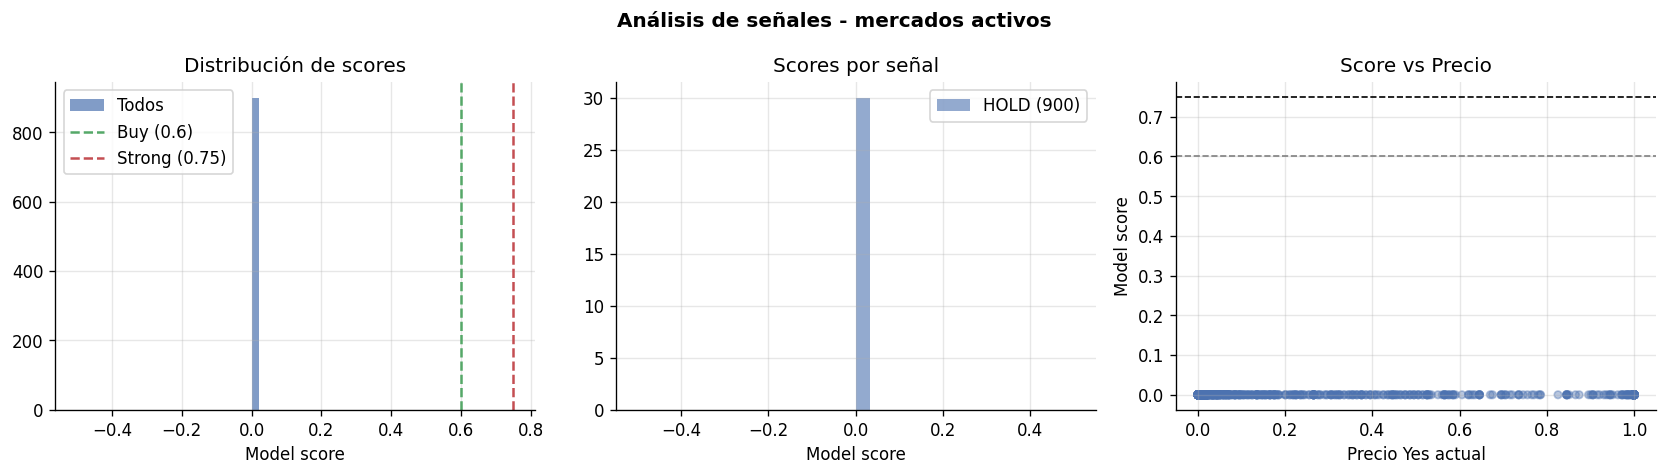

In [5]:
df_filtered = df_scores[df_scores['signal'].isin(['BUY', 'STRONG BUY'])].copy()

print(f'Señales finales (ya filtradas por calidad): {len(df_filtered):,}')
print(f"  BUY:         {(df_filtered['signal'] == 'BUY').sum():,}")
print(f"  STRONG BUY:  {(df_filtered['signal'] == 'STRONG BUY').sum():,}")
print(
    f'  Filtros activos: liquidez≥${MIN_LIQUIDITY:,.0f}, '
    f'vol24h≥${MIN_VOLUME_24H:,.0f}, spread≤{MAX_SPREAD:.0%}'
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.hist(df_scores['model_score'], bins=50, color=PALETTE[0], alpha=0.7, label='Todos')
ax.axvline(BUY_THRESHOLD, color=PALETTE[2], linestyle='--', lw=1.5, label=f'Buy ({BUY_THRESHOLD})')
ax.axvline(STRONG_BUY_THRESHOLD, color=PALETTE[3], linestyle='--', lw=1.5, label=f'Strong ({STRONG_BUY_THRESHOLD})')
ax.set_title('Distribución de scores')
ax.set_xlabel('Model score')
ax.legend()

ax = axes[1]
signal_order = ['HOLD', 'BUY', 'STRONG BUY']
colors_map = {'HOLD': PALETTE[0], 'BUY': PALETTE[2], 'STRONG BUY': PALETTE[3]}
for signal in signal_order:
    sub = df_scores[df_scores['signal'] == signal]['model_score']
    if len(sub) > 0:
        ax.hist(sub, bins=30, alpha=0.6, color=colors_map[signal], label=f'{signal} ({len(sub):,})', density=True)
ax.set_title('Scores por señal')
ax.set_xlabel('Model score')
ax.legend()

ax = axes[2]
ax.scatter(
    df_scores['price_yes'],
    df_scores['model_score'],
    c=[colors_map[signal] for signal in df_scores['signal']],
    alpha=0.4,
    s=20,
)
ax.axhline(BUY_THRESHOLD, color='gray', linestyle='--', lw=1)
ax.axhline(STRONG_BUY_THRESHOLD, color='black', linestyle='--', lw=1)
ax.set_xlabel('Precio Yes actual')
ax.set_ylabel('Model score')
ax.set_title('Score vs Precio')

plt.suptitle('Análisis de señales - mercados activos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'scoring_signals.png', bbox_inches='tight')
plt.show()


## 5. Backtesting sobre mercados resueltos

Simulamos cómo habría rendido la señal del modelo en mercados que ya resolvieron.
Usamos el precio snapshot (7 días antes del endDate) como precio de entrada
para evitar leakage desde el precio final.


In [6]:
with open(RAW / 'resolved_markets.json') as f:
    resolved_markets = json.load(f)

BACKTEST_SAMPLE = 2000
sample = resolved_markets[:BACKTEST_SAMPLE]

backtest_rows = []
skipped_bt = {'no_snapshot': 0, 'ambiguous': 0, 'exceptions': 0}

for market in sample:
    market_id = str(market.get('id', ''))
    history = price_histories.get(market_id)
    market_snapshot, snapshot_price = build_snapshot_market(
        market,
        price_histories,
        snapshot_offset_days=FEATURE_CFG['snapshot_offset_days'],
        use_adaptive_cutoff=FEATURE_CFG.get('adaptive_cutoff', True),
    )
    if market_snapshot is None or snapshot_price is None:
        skipped_bt['no_snapshot'] += 1
        continue

    try:
        features = pipeline.transform_single(market_snapshot, price_history=history)
        num_t = torch.FloatTensor(features['numerical']).unsqueeze(0).to(device)
        cat_t = torch.LongTensor([features['category_id']]).to(device)
        txt_t = torch.FloatTensor(features['text_embedding']).unsqueeze(0).to(device)

        with torch.no_grad():
            score = model(num_t, cat_t, txt_t).item()

        resolution = infer_resolution_from_market(market)
        if resolution not in ('yes', 'no'):
            skipped_bt['ambiguous'] += 1
            continue

        backtest_rows.append({
            'id': market_id,
            'question': market.get('question', '')[:60],
            'snap_price': snapshot_price,
            'score': score,
            'signal': 'STRONG BUY' if score >= STRONG_BUY_THRESHOLD else ('BUY' if score >= BUY_THRESHOLD else 'HOLD'),
            'resolved': 1 if resolution == 'yes' else 0,
        })
    except Exception:
        skipped_bt['exceptions'] += 1

df_bt = pd.DataFrame(backtest_rows)
print(f'Muestra backtest: {len(df_bt):,} mercados')
print('  Omitidos:')
for key, value in skipped_bt.items():
    print(f'    {key}: {value:,}')
print()
print('-' * 50)
print('Win rate por señal:')
for signal in ['STRONG BUY', 'BUY', 'HOLD']:
    sub = df_bt[df_bt['signal'] == signal]
    if len(sub) == 0:
        continue
    win_rate = sub['resolved'].mean()
    print(f'  {signal:12s}: {len(sub):>4,} trades | {100 * win_rate:.1f}% Yes')


Muestra backtest: 1,954 mercados
  Omitidos:
    no_snapshot: 0
    ambiguous: 46
    exceptions: 0

--------------------------------------------------
Win rate por señal:
  STRONG BUY  :  296 trades | 86.1% Yes
  BUY         :   26 trades | 53.8% Yes
  HOLD        : 1,632 trades | 15.7% Yes


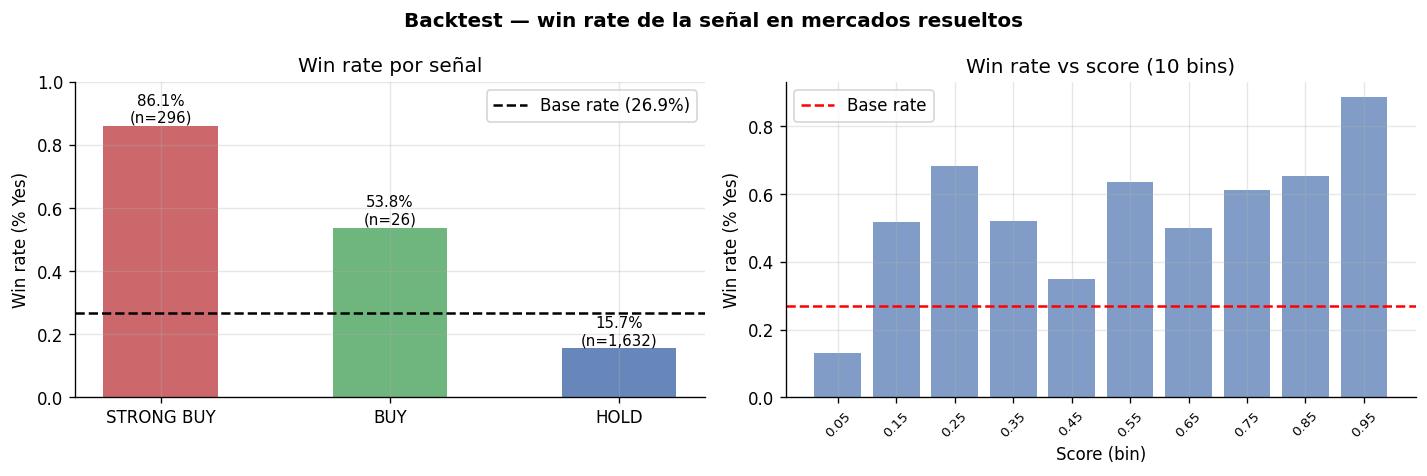

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Win rate por señal
ax = axes[0]
sig_order = ['STRONG BUY', 'BUY', 'HOLD']
sig_colors = [PALETTE[3], PALETTE[2], PALETTE[0]]
wr_vals = []
counts = []
for sig in sig_order:
    sub = df_bt[df_bt['signal'] == sig]
    wr_vals.append(sub['resolved'].mean() if len(sub) > 0 else 0)
    counts.append(len(sub))
bars = ax.bar(sig_order, wr_vals, color=sig_colors, alpha=0.85, width=0.5)
for bar, wr, cnt in zip(bars, wr_vals, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{100*wr:.1f}%\n(n={cnt:,})', ha='center', fontsize=9)
ax.axhline(df_bt['resolved'].mean(), color='black', linestyle='--', lw=1.5, label=f'Base rate ({100*df_bt["resolved"].mean():.1f}%)')
ax.set_ylim(0, 1)
ax.set_ylabel('Win rate (% Yes)')
ax.set_title('Win rate por señal')
ax.legend()

# Score vs win rate (binned)
ax = axes[1]
df_bt['score_bin'] = pd.cut(df_bt['score'], bins=10)
wr_by_bin = df_bt.groupby('score_bin', observed=True)['resolved'].agg(['mean', 'count'])
bin_centers = [iv.mid for iv in wr_by_bin.index]
ax.bar(range(len(wr_by_bin)), wr_by_bin['mean'], color=PALETTE[0], alpha=0.7)
ax.axhline(df_bt['resolved'].mean(), color='red', linestyle='--', lw=1.5, label='Base rate')
ax.set_xticks(range(len(wr_by_bin)))
ax.set_xticklabels([f'{c:.2f}' for c in bin_centers], rotation=45, fontsize=8)
ax.set_xlabel('Score (bin)')
ax.set_ylabel('Win rate (% Yes)')
ax.set_title('Win rate vs score (10 bins)')
ax.legend()

plt.suptitle('Backtest — win rate de la señal en mercados resueltos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'scoring_backtest_winrate.png', bbox_inches='tight')
plt.show()

## 6. Simulación de P&L

Simulamos P&L con position sizing fijo (5% del capital por trade).
Compramos Yes al precio snapshot reconstruido de forma anti-leakage
cuando la señal es BUY o STRONG BUY.


In [8]:
INITIAL_CAPITAL = 1_000.0
POSITION_SIZE   = 0.05  # 5% del capital por trade

# Filtrar solo señales de compra (sin HOLD) con precio válido
df_trades = df_bt[
    (df_bt['signal'].isin(['BUY', 'STRONG BUY'])) &
    (df_bt['snap_price'] > 0.01) &
    (df_bt['snap_price'] < 0.99)
].copy().reset_index(drop=True)

capital = INITIAL_CAPITAL
equity_curve = [capital]
trade_log = []

for _, row in df_trades.iterrows():
    bet = capital * POSITION_SIZE
    price = row['snap_price']
    shares = bet / price
    payout = shares * float(row['resolved'])  # 1 si Yes, 0 si No
    pnl = payout - bet
    capital += pnl
    equity_curve.append(capital)
    trade_log.append({
        'signal':    row['signal'],
        'price':     price,
        'resolved':  int(row['resolved']),
        'pnl':       pnl,
        'capital':   capital,
    })

df_log = pd.DataFrame(trade_log)
final_capital = capital
total_return = (final_capital / INITIAL_CAPITAL - 1) * 100
win_rate_bt = df_log['resolved'].mean()
avg_pnl = df_log['pnl'].mean()

print(f"Simulación P&L — {len(df_log)} trades")
print(f"  Capital inicial:  ${INITIAL_CAPITAL:,.2f}")
print(f"  Capital final:    ${final_capital:,.2f}")
print(f"  Retorno total:    {total_return:+.2f}%")
print(f"  Win rate:         {100*win_rate_bt:.1f}%")
print(f"  PnL promedio:     ${avg_pnl:+.2f} por trade")
print(f"  Trades ganadores: {df_log['resolved'].sum():.0f}")
print(f"  Trades perdedores:{(1-df_log['resolved']).sum():.0f}")

Simulación P&L — 267 trades
  Capital inicial:  $1,000.00
  Capital final:    $1,048,653.86
  Retorno total:    +104765.39%
  Win rate:         80.1%
  PnL promedio:     $+3923.80 por trade
  Trades ganadores: 214
  Trades perdedores:53


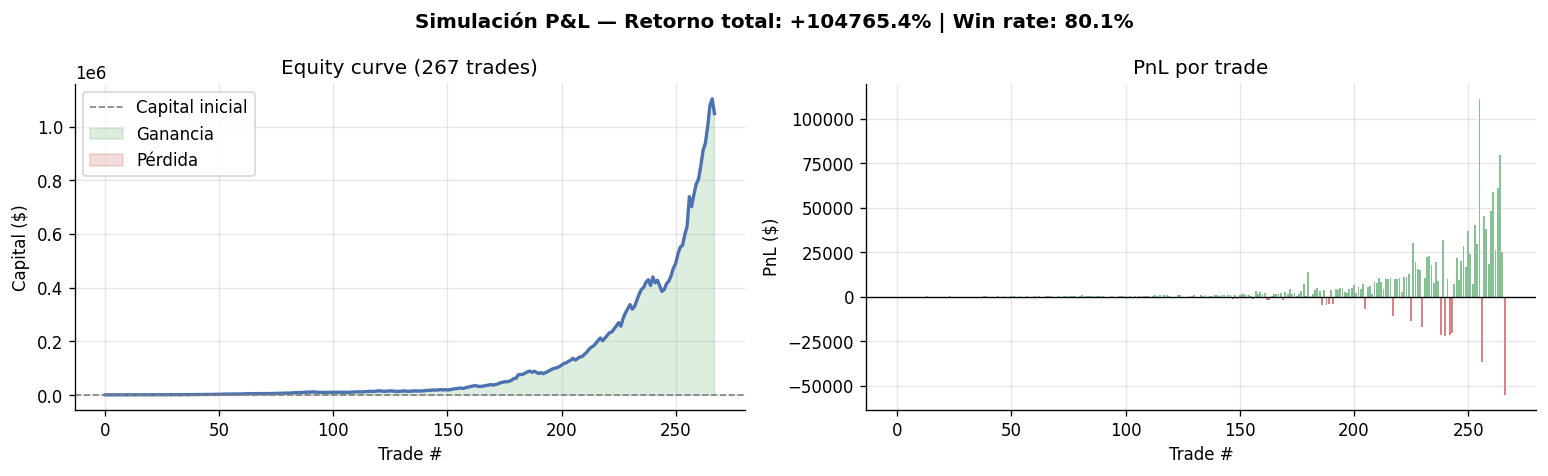


NOTA: Esta simulación no incluye comisiones ni impacto de mercado.
El model_score NO es una probabilidad calibrada — interpretar como ranking relativo.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Equity curve
ax = axes[0]
ax.plot(equity_curve, color=PALETTE[0], lw=2)
ax.axhline(INITIAL_CAPITAL, color='gray', linestyle='--', lw=1, label='Capital inicial')
ax.fill_between(range(len(equity_curve)), INITIAL_CAPITAL, equity_curve,
                where=[e >= INITIAL_CAPITAL for e in equity_curve],
                alpha=0.2, color=PALETTE[2], label='Ganancia')
ax.fill_between(range(len(equity_curve)), INITIAL_CAPITAL, equity_curve,
                where=[e < INITIAL_CAPITAL for e in equity_curve],
                alpha=0.2, color=PALETTE[3], label='Pérdida')
ax.set_title(f'Equity curve ({len(df_log)} trades)')
ax.set_xlabel('Trade #')
ax.set_ylabel('Capital ($)')
ax.legend()

# PnL por trade
ax = axes[1]
colors_pnl = [PALETTE[2] if p > 0 else PALETTE[3] for p in df_log['pnl']]
ax.bar(range(len(df_log)), df_log['pnl'], color=colors_pnl, alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('PnL por trade')
ax.set_xlabel('Trade #')
ax.set_ylabel('PnL ($)')

plt.suptitle(f'Simulación P&L — Retorno total: {total_return:+.1f}% | Win rate: {100*win_rate_bt:.1f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'scoring_pnl_simulation.png', bbox_inches='tight')
plt.show()

print("\nNOTA: Esta simulación no incluye comisiones ni impacto de mercado.")
print("El model_score NO es una probabilidad calibrada — interpretar como ranking relativo.")